**AI STATEMENT**

AI (Mainly ChatGPT) has been used in this assignment for troubleshooting as well as for giving ideas to ensuring that the table formats stay exactly the same in tasks involving table transformations (such as Task 8). AI has also been used to help develop the more complex SQL queries.

### Task 0: Course project dataset exploration (2p)

This task is meant to help you start thinking about the course project. The choice you make here is not binding and you can change your topic and dataset later.

a) Find a potential dataset for the course project. This can be either an existing dataset (e.g. from Kaggle, a government open data portal, or another source) or an API that you plan to use for data collection. Provide the name and a link to the source. (0.5p)

b) Briefly describe the dataset in a markdown cell: what it contains, what variables it has, how many rows there are (or how many you plan to collect if using an API), and what you plan to do with it in the project. (0.5p)

c) Conduct exploratory data analysis on the dataset (or on a sample of the data you plan to collect). This includes computing summary statistics (e.g. using `.describe()`) and creating at least 2 visualizations of the data. (1p)

**a)**

In [1]:
import kagglehub
import pandas as pd

#downloading data from Kaggle
path = kagglehub.dataset_download("belbino/global-fuel-prices-20202026")

#The data is from Kaggle, called 'Global Fuel Prices 2020–2026'. 
#Link: https://www.kaggle.com/datasets/belbino/global-fuel-prices-20202026

print("Path to dataset files:", path)

Path to dataset files: /Users/felix/.cache/kagglehub/datasets/belbino/global-fuel-prices-20202026/versions/1


In [2]:
project_df=pd.read_csv('/Users/felix/.cache/kagglehub/datasets/belbino/global-fuel-prices-20202026/versions/1/global_fuel_prices_2020_2026.csv')

**b)**

The dataset contains fuel price data for different fuels, as well as the price for a barrel of brent crude oil in USD. The dataset also contains information on country-specific fuel taxes, subsidies and income-levels.

The dataset consists of 27,468 observations in weekly format from 84 different countries. 

My plan consists of the following: performing statistical methods to determine how well oil price changes show in fuel prices and/or determine if subsidies impact fuel prices (for example if they stabilise fuel prices or reduce the impact of shocks in the oil market.) This is to be done via regressions, however this project is still very much in the planning phase and I haven't decided on my final methodology yet.


**c)**

In [3]:
project_df.describe().round()

,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
count,27468.0,27468.0,27468.0,27468.0,27468.0
mean,2.0,2.0,2.0,107.0,27.0
std,2.0,1.0,1.0,19.0,17.0
min,0.0,0.0,0.0,48.0,0.0
25%,1.0,1.0,1.0,101.0,14.0
50%,2.0,2.0,2.0,112.0,23.0
75%,3.0,3.0,3.0,119.0,39.0
max,7.0,6.0,5.0,130.0,65.0


In [4]:
project_df.head()

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,2020-01-13,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6
2,2020-01-20,United States,North America,High,Low,1.446,1.329,1.080,66.51,62.3
3,2020-01-27,United States,North America,High,Low,1.488,1.359,1.125,68.79,44.8
4,2020-02-03,United States,North America,High,Low,1.457,1.341,1.111,68.44,51.4


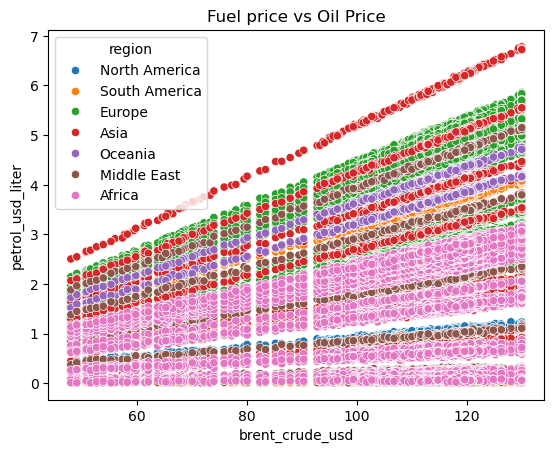

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(data=project_df, x="brent_crude_usd", y="petrol_usd_liter", hue="region")
plt.title("Fuel price vs Oil Price")
plt.show()

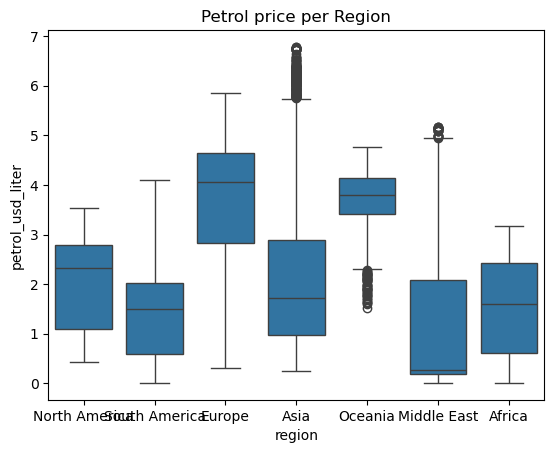

In [6]:
sns.boxplot(data=project_df, x="region", y="petrol_usd_liter")
plt.title("Petrol price per Region")
plt.show()

### Task 1: Setting up an API key and .env file (1p)

Set up an account and get a free-tier API key at [https://marketstack.com/](https://marketstack.com/) (no bank details required).

Store the API key in a `.env` file and load it in your notebook using `python-dotenv`. Print out only the first 5 characters of the key (e.g. `print(api_key[:5] + "...")`) to confirm it loaded correctly. Make sure the output is visible in the submitted notebook.

**Important:** Do not include the `.env` file in your GitHub repository. Add `.env` to your `.gitignore`. The API key must not be fully visible anywhere in the notebook or repository.

In [7]:

from dotenv import load_dotenv
import os

os.chdir("/Users/felix/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/Python4BusinessInt") #setting the directory as I had some issues with reading the .env file

load_dotenv()

SECRET_KEY = os.getenv('MY_API_KEY')

print(f'My key begins with: {SECRET_KEY[:5]}....')


My key begins with: 1373c....


### Task 2: Retrieving data from MarketStack (1p)

Use the [MarketStack API](https://docs.apilayer.com/marketstack/docs/api-documentation?utm_source=dashboard&utm_medium=Referral) to investigate how the FAANG stocks performed in March 2026. The FAANG companies and their ticker symbols are: Facebook/Meta (META), Apple (AAPL), Amazon (AMZN), Netflix (NFLX), and Google/Alphabet (GOOG).

a) Retrieve End-of-Day (eod) data for these five stocks for March 2026. Note: Each ticker in a request counts as a separate API call against your monthly limit, so plan your requests accordingly. Retrieving the data once should take only 5% of the monthly free API calls.

b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows.

c) Compute summary statistics for the closing prices grouped by stock. Also calculate the return percentage for each stock over the month (i.e. the percentage change from the first to the last trading day). Print out the computed numbers or a DataFrame that contains the numbers, and report which stock performed best and which worst in March 2026.

Hint: The API documentation helps on how to use it, but also using AI is recommended to help with formulating the GET request if you get stuck. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [8]:
#Task a)
import requests
import pandas as pd
url = "https://api.marketstack.com/v1/eod"
querystring = {"access_key":SECRET_KEY,"symbols":"AAPL,META,AMZN,NFLX,GOOG","date_from":"2026-03-01","date_to":"2026-03-31"}
response = requests.get(url, params=querystring)


In [9]:
data = response.json()["data"]
data[:5]

[{'open': 247.89,
  'high': 255.48,
  'low': 247.101,
  'close': 253.79,
  'volume': 48770963.0,
  'adj_high': 255.48,
  'adj_low': 247.101,
  'adj_close': 253.79,
  'adj_open': 247.91,
  'adj_volume': 49598091.0,
  'split_factor': 1.0,
  'dividend': 0.0,
  'symbol': 'AAPL',
  'exchange': 'XNAS',
  'date': '2026-03-31T00:00:00+0000'},
 {'open': 204.875,
  'high': 210.28,
  'low': 204.14,
  'close': 208.27,
  'volume': 57843337.0,
  'adj_high': 210.28,
  'adj_low': 204.14,
  'adj_close': 208.27,
  'adj_open': 204.845,
  'adj_volume': 58470078.0,
  'split_factor': 1.0,
  'dividend': 0.0,
  'symbol': 'AMZN',
  'exchange': 'XNAS',
  'date': '2026-03-31T00:00:00+0000'},
 {'open': 277.84,
  'high': 287.05,
  'low': 276.81,
  'close': 286.86,
  'volume': 30680107.0,
  'adj_high': 287.05,
  'adj_low': 276.76,
  'adj_close': 286.86,
  'adj_open': 277.54,
  'adj_volume': 31625057.0,
  'split_factor': 1.0,
  'dividend': 0.0,
  'symbol': 'GOOG',
  'exchange': 'XNAS',
  'date': '2026-03-31T00:00:00

In [10]:
df = pd.DataFrame(data)
df["date"] = pd.to_datetime(df["date"]).dt.date #the original data also included the timestamp so I decided to clean it up a bit.
df = df.sort_values(["symbol", "date"])
df.head(5)

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
95,264.650,266.150,261.4200,262.52,39258957.0,266.150,261.4200,262.52,264.650,39803119.0,1.0,0.0,AAPL,XNAS,2026-03-04
90,260.745,261.555,257.2500,260.29,49424671.0,261.555,257.2500,260.29,260.790,49658626.0,1.0,0.0,AAPL,XNAS,2026-03-05
85,258.740,258.760,254.3700,257.46,40628988.0,258.770,254.3700,257.46,258.630,41120042.0,1.0,0.0,AAPL,XNAS,2026-03-06
80,255.690,261.150,253.6805,259.88,37958303.0,261.150,253.6805,259.88,255.690,38218533.0,1.0,0.0,AAPL,XNAS,2026-03-09
75,257.695,262.480,256.9500,260.83,26403306.0,262.480,256.9500,260.83,257.645,30590765.0,1.0,0.0,AAPL,XNAS,2026-03-10


**Task c)**

In [11]:
df.groupby('symbol')["close"].describe().reset_index()

,symbol,count,mean,std,min,25%,50%,75%,max
0,AAPL,20.0,253.9735,4.843451,246.63,250.0750,252.855,258.0650,262.52
1,AMZN,20.0,210.1385,4.856686,199.34,207.6375,210.005,213.2800,218.94
2,GOOG,20.0,297.2825,11.232111,273.14,289.4925,301.185,305.8000,309.41
3,META,20.0,611.0580,41.315247,525.72,593.4750,614.695,645.4925,667.73
4,NFLX,20.0,94.8445,2.518470,90.92,93.2325,94.530,96.3475,99.17


In [12]:
returns = df.groupby("symbol")["close"].apply(
    lambda x: x.iloc[-1] / x.iloc[0] - 1
).reset_index(name="pct_change")

returns["pct_change"] = returns["pct_change"] * 100 #converting to %

best_company = returns.loc[returns["pct_change"].idxmax(), "symbol"]
worst_company = returns.loc[returns["pct_change"].idxmin(), "symbol"]

print(f"The best company was {best_company} and the worst company was {worst_company}.")

returns


The best company was NFLX and the worst company was META.


,symbol,pct_change
0,AAPL,-3.325461
1,AMZN,-3.943363
2,GOOG,-5.467128
3,META,-14.317164
4,NFLX,-2.544091


### Task 3: Visualizing stock data (1p)

Using the data from Task 2, create the following visualizations with seaborn:

a) A line chart showing the closing price of each stock over time during March 2026. The x-axis should be the date and the y-axis the closing price. Use distinct colors for each stock and include a legend.

b) A bar plot showing the overall return percentage for each stock in March 2026.

c) A heatmap showing the daily trading volume for each stock (stocks on the y axis, dates on the x axis).

**Task a)**

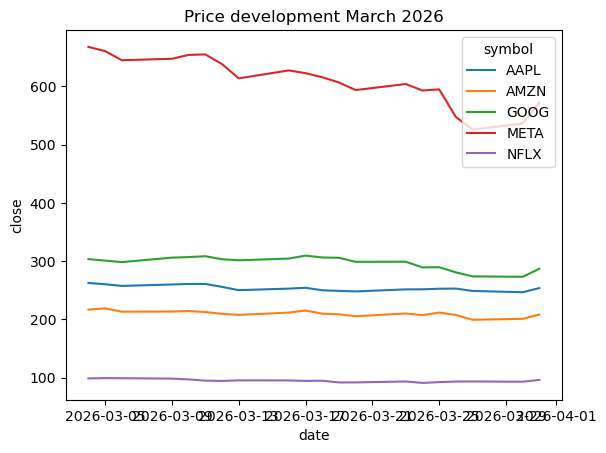

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.lineplot(x="date", y="close", hue="symbol", legend = True, data=df)
plt.title("Price development March 2026")
plt.show()

**Task b)**

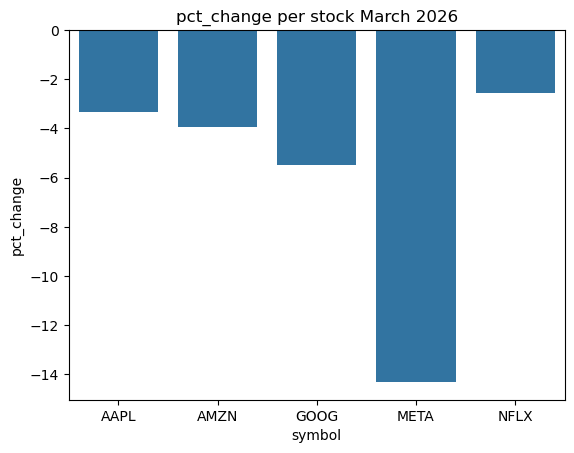

In [14]:
sns.barplot(x="symbol", y="pct_change", data=returns)
plt.title("pct_change per stock March 2026")
plt.show()

**Task c)**

<function matplotlib.pyplot.show(close=None, block=None)>

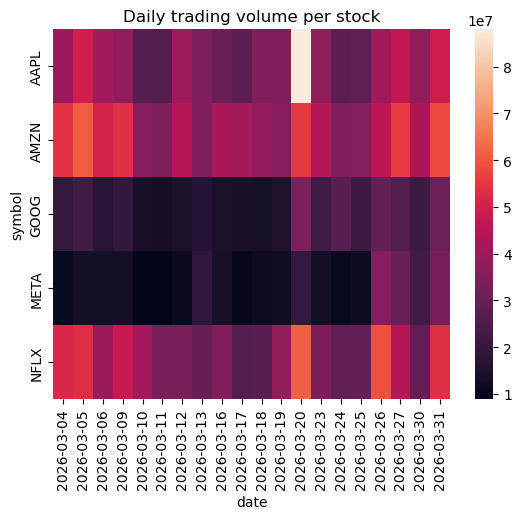

In [15]:
heatmap_data = df.pivot(index="symbol", columns="date", values="volume") #transforming the data into a format that suits the heatmap
sns.heatmap(data=heatmap_data)
plt.title("Daily trading volume per stock")
plt.show

### Task 4: Exporting and importing data (1p)

a) Export the JSON data retrieved in Task 2a as a JSON file `stockdata.json` into a subfolder called `exports`.

b) Export the DataFrame from Task 2b as a CSV file `stockdata.csv` into the same `exports` subfolder.

c) Load back the exported data from both a) and b). Print the first five rows of each and verify that the data looks identical to what it was in Task 2.

**Task a)**

In [16]:
os.makedirs("exports", exist_ok=True)#creating the subfolder

with open("exports/stockdata.json", "w") as f: 
    json.dump(data, f, indent=4)

**Task b)**

In [17]:
df.to_csv('exports/stockdata.csv')

**Task c)**

In [18]:
import json

with open("exports/stockdata.json", "r") as file:
    data = json.load(file)

print(json.dumps(data[:5], indent=0))

[
{
"open": 247.89,
"high": 255.48,
"low": 247.101,
"close": 253.79,
"volume": 48770963.0,
"adj_high": 255.48,
"adj_low": 247.101,
"adj_close": 253.79,
"adj_open": 247.91,
"adj_volume": 49598091.0,
"split_factor": 1.0,
"dividend": 0.0,
"symbol": "AAPL",
"exchange": "XNAS",
"date": "2026-03-31T00:00:00+0000"
},
{
"open": 204.875,
"high": 210.28,
"low": 204.14,
"close": 208.27,
"volume": 57843337.0,
"adj_high": 210.28,
"adj_low": 204.14,
"adj_close": 208.27,
"adj_open": 204.845,
"adj_volume": 58470078.0,
"split_factor": 1.0,
"dividend": 0.0,
"symbol": "AMZN",
"exchange": "XNAS",
"date": "2026-03-31T00:00:00+0000"
},
{
"open": 277.84,
"high": 287.05,
"low": 276.81,
"close": 286.86,
"volume": 30680107.0,
"adj_high": 287.05,
"adj_low": 276.76,
"adj_close": 286.86,
"adj_open": 277.54,
"adj_volume": 31625057.0,
"split_factor": 1.0,
"dividend": 0.0,
"symbol": "GOOG",
"exchange": "XNAS",
"date": "2026-03-31T00:00:00+0000"
},
{
"open": 549.98,
"high": 573.69,
"low": 546.77,
"close": 572.13,
"vol

Data is the same. Format differs a little.

In [19]:
csv_df = pd.read_csv("exports/stockdata.csv")
csv_df = csv_df.drop(columns=["Unnamed: 0"]) #dropping the unwanted column so ensure that the formatting is the same.
csv_df.head(5)

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,264.650,266.150,261.4200,262.52,39258957.0,266.150,261.4200,262.52,264.650,39803119.0,1.0,0.0,AAPL,XNAS,2026-03-04
1,260.745,261.555,257.2500,260.29,49424671.0,261.555,257.2500,260.29,260.790,49658626.0,1.0,0.0,AAPL,XNAS,2026-03-05
2,258.740,258.760,254.3700,257.46,40628988.0,258.770,254.3700,257.46,258.630,41120042.0,1.0,0.0,AAPL,XNAS,2026-03-06
3,255.690,261.150,253.6805,259.88,37958303.0,261.150,253.6805,259.88,255.690,38218533.0,1.0,0.0,AAPL,XNAS,2026-03-09
4,257.695,262.480,256.9500,260.83,26403306.0,262.480,256.9500,260.83,257.645,30590765.0,1.0,0.0,AAPL,XNAS,2026-03-10


Ok. Same as the original.

### Task 5: Querying the Northwind database (1p)

Download an SQLite version of Microsoft's Northwind database (from [https://github.com/jpwhite3/northwind-SQLite3](https://github.com/jpwhite3/northwind-SQLite3), press the Download Here button). Connect to the database using `sqlite3`.

a) Connect to the database and list all tables it contains (print the table names).

b) Write a SQL query that retrieves all products with a unit price above 30, showing `ProductName`, `UnitPrice`, and `UnitsInStock`. Load the result into a DataFrame and print it.

c) Write a SQL query that joins the `Orders`, `Customers`, and `Order Details` tables to show `CompanyName`, `OrderID`, `OrderDate`, `ShipCountry`, and the line total (`UnitPrice * Quantity`) for all orders shipped to Germany. Load the result into a DataFrame and print it. Note, order details needs to be written as 'Order Details' within the quotation marks in the query since it consists of two words as the table name.

Hint: The SQL query in 5c should look something like this:

```
    SELECT columnNameX,
           columnNameX,
           columnNameX,
           columnNameX,
           columnNameX * columnNameX AS LineTotal
    FROM SomeTable o
    JOIN SomeTable c ON SomeTable.id = OtherTable.id
    JOIN SomeTable od ON SomeTable.id = OtherTable.id
    WHERE columnName = countryName
```

Hint: If you are unfamiliar with SQL, using AI to write the queries is a good idea. Remember to verify though that the column and table names are correct and not hallucinated. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

**Task a)**

In [20]:
import sqlite3

con = sqlite3.connect("northwind.db")

In [21]:
sql_query = """SELECT name FROM sqlite_master  
  WHERE type='table';"""

tables = pd.read_sql(sql_query, con)
print(tables)

                    name
0             Categories
1        sqlite_sequence
2   CustomerCustomerDemo
3   CustomerDemographics
4              Customers
5              Employees
6    EmployeeTerritories
7          Order Details
8                 Orders
9               Products
10               Regions
11              Shippers
12             Suppliers
13           Territories


**Task b)**

In [22]:
sql_products_query = """SELECT ProductName, UnitPrice, UnitsInStock FROM Products WHERE UnitPrice > 30"""

products_df = pd.read_sql(sql_products_query, con)
print(products_df)

                   ProductName  UnitPrice  UnitsInStock
0   Northwoods Cranberry Sauce      40.00             6
1              Mishi Kobe Niku      97.00            29
2                        Ikura      31.00            31
3    Queso Manchego La Pastora      38.00            86
4                 Alice Mutton      39.00             0
5             Carnarvon Tigers      62.50            42
6       Sir Rodney's Marmalade      81.00            40
7          Gumbär Gummibärchen      31.23            15
8           Schoggi Schokolade      43.90            49
9            Rössle Sauerkraut      45.60            26
10     Thüringer Rostbratwurst     123.79             0
11          Mascarpone Fabioli      32.00             9
12               Côte de Blaye     263.50            17
13                 Ipoh Coffee      46.00            17
14       Manjimup Dried Apples      53.00            20
15               Perth Pasties      32.80             0
16      Gnocchi di nonna Alice      38.00       

**Task c)**

In [23]:
query5c = """
SELECT CompanyName, o.OrderID, OrderDate, ShipCountry, UnitPrice * Quantity AS LineTotal
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN [Order Details] d ON o.OrderID = d.OrderID
WHERE ShipCountry = 'Germany';"""

query_result = pd.read_sql(query5c, con)

query_result



,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.0


### Task 6: Visualizing Northwind data (1p)

Using the query results from Task 5, create the following visualizations:

a) Using the result from Task 5c, create a bar plot showing the number of orders per customer (for the top 10 customers who shipped to Germany).

b) Using the result from Task 5c, compute the total sales per order date and create a density plot (KDE plot) of daily total sales for orders shipped to Germany. The density plot shows the distribution of sales volumes, i.e., makes it easy to see the typical size of daily sales volumes.

c) Write a new SQL query that joins `OrderDetails`, `Products`, and `Categories` using inner joins to compute the total revenue (`UnitPrice * Quantity`) per product category. Load the result into a DataFrame and create a bar plot showing total revenue by category.

Hint: The SQL query in 6c should look something like this:

```
    SELECT columnName1,
           SUM(columnName2 * columnName3) AS newColumnName
    FROM table1 od
    JOIN table2 p ON table1_id = table2_id
    JOIN table3 cat ON table2_id = table3_id
    GROUP BY columnName1
```

**Task a)**

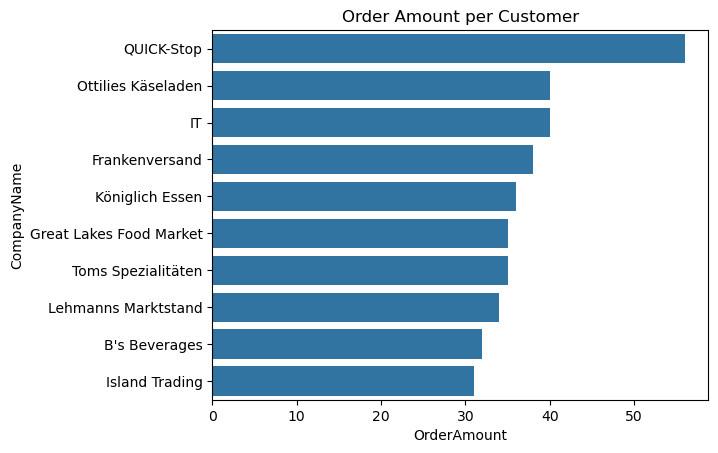

,OrderAmount
CompanyName,
QUICK-Stop,56
Ottilies Käseladen,40
IT,40
Frankenversand,38
Königlich Essen,36
Great Lakes Food Market,35
Toms Spezialitäten,35
Lehmanns Marktstand,34
B's Beverages,32


In [24]:
orders_per_customer = (
    query_result.groupby("CompanyName")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

orders_per_customer = pd.DataFrame(orders_per_customer)

orders_per_customer.rename(columns={"OrderID":"OrderAmount"}, inplace=True)


sns.barplot(x="OrderAmount", y="CompanyName", data=orders_per_customer)
plt.title("Order Amount per Customer")
plt.show()

orders_per_customer

**Task b)**

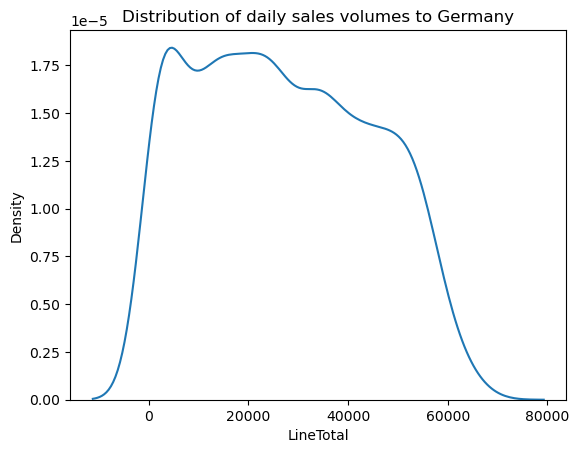

In [25]:
daily_sales = (
    query_result.groupby("OrderDate")["LineTotal"]
    .sum()
    .reset_index()
)

sns.kdeplot(data=daily_sales, x="LineTotal")
plt.title("Distribution of daily sales volumes to Germany")
plt.show()

**Task c)**

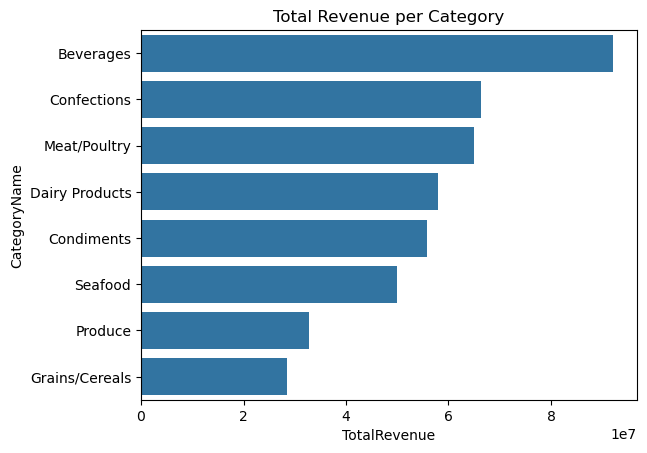

,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55


In [26]:
query6c = """SELECT 
    c.CategoryName,
    SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM [Order Details] od
JOIN Products p 
    ON od.ProductID = p.ProductID
JOIN Categories c 
    ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
ORDER BY TotalRevenue DESC;"""

result6c = pd.read_sql(query6c, con)

sns.barplot(data=result6c, x="TotalRevenue", y="CategoryName")
plt.title("Total Revenue per Category")
plt.show()

result6c

### Task 7: Comparing Python to SQL (1p)

a) Write a SQL query that retrieves the full `Products` table and the full `Categories` table into separate DataFrames. Print the first 5 rows of each.

b) Using pandas, perform an inner join on the two DataFrames from 7a on `CategoryID`.

c) Replicate with Python the SQL code of Task 6c, retrieving first the tables fully using SQL and joining them with pandas. Using `%%time` or `time.time()`, compare the execution speed of performing the join fully with SQL (as in 6c) versus performing it in Python with pandas after retrieving via SQL the tables only (similar to what was done in Task 7a-b). Print both execution times and briefly comment on which was faster.

**Task a)**

In [27]:
products_df = pd.read_sql("SELECT * FROM Products", con)
categories_df = pd.read_sql("SELECT * FROM Categories", con)

products_df.head()


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


In [28]:
categories_df.head()

,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


**Task b)**

In [29]:
joined_df = pd.merge(products_df, categories_df, on='CategoryID', how='inner')
joined_df.head()

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


**Task c)**

In [30]:
import time

start_py = time.time()

order_details_df = pd.read_sql("SELECT * FROM [Order Details];", con)
products_df = pd.read_sql("SELECT * FROM Products;", con)
categories_df = pd.read_sql("SELECT * FROM Categories;", con)

merged_df = pd.merge(order_details_df, products_df, on="ProductID", how="inner")
merged_df = pd.merge(merged_df, categories_df, on="CategoryID", how="inner")

merged_df["TotalRevenue"] = merged_df["UnitPrice_x"] * merged_df["Quantity"]

python_result = (
    merged_df.groupby("CategoryName", as_index=False)["TotalRevenue"]
    .sum()
    .sort_values("TotalRevenue", ascending=False)
)

end_py = time.time()

python_time = end_py - start_py

print(python_result)
print("Pandas execution time:", python_time)


     CategoryName  TotalRevenue
0       Beverages   92181842.95
2     Confections   66347544.94
5    Meat/Poultry   64896314.41
3  Dairy Products   58034940.00
1      Condiments   55802774.45
7         Seafood   49931965.52
6         Produce   32706403.90
4  Grains/Cereals   28573512.55
Pandas execution time: 0.8038098812103271


In [31]:
start_sql = time.time()
sql_result = pd.read_sql(query6c, con)
end_sql = time.time()

sql_time = end_sql - start_sql

print(sql_result)
print("SQL execution time:", sql_time)
con.close()

     CategoryName  TotalRevenue
0       Beverages   92181842.95
1     Confections   66347544.94
2    Meat/Poultry   64896314.41
3  Dairy Products   58034940.00
4      Condiments   55802774.45
5         Seafood   49931965.52
6         Produce   32706403.90
7  Grains/Cereals   28573512.55
SQL execution time: 0.27641773223876953


As we can see, the SQLite version is faster.

### Task 8: Wide and long format (1p)

You are given two datasets. The first is in wide format:

```python
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})
```

The second is in long format:

```python
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})
```

a) Convert `wide_data` from wide to long format using `pd.melt()`. Print the DataFrame before and after conversion.

b) Convert `long_data` from long to wide format using `.pivot()`. Print the DataFrame before and after conversion.

c) Convert both transformed datasets back to their original format. Print the datasets before and after to confirm they match the originals.

In [32]:
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

In [33]:
wide_data

,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


In [34]:
long_data

,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


**Task a)**

In [35]:
wide_data_long=pd.melt(wide_data, id_vars=['store'], value_vars=['Q1_sales','Q2_sales','Q3_sales','Q4_sales'])
wide_data_long

,store,variable,value
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


**Task b)**

In [36]:
long_data_wide=long_data.pivot(index='month', columns='product', values='units_sold').reset_index()
long_data_wide

product,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


**Task c)**

In [37]:
wide_data_restored=wide_data_long.pivot(index='store', columns=['variable'], values='value').reset_index()
wide_data_restored.columns.name = None #to ensure that formatting stays the same
wide_data_restored

,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


In [38]:
long_data_restored=pd.melt(long_data_wide, id_vars=['month'], var_name='product', value_name='units_sold')

long_data_restored = long_data_restored.sort_values(
    by=["month", "product"],
    key=lambda col: pd.to_datetime(col, format="%b") if col.name == "month" else col #This is done the correct the order.
).reset_index(drop=True)
#The lambda function temporarily changes the month to a date format that it uses for sorting. The sort_values command first sorts the month, and then the products within that month.
long_data_restored


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


Both tables are the same as the originals.